# 01 - EDA : Données Statiques RH

## Objectif
Ce notebook couvre l'analyse exploratoire des **3 fichiers statiques** :
- Données générales des employés
- Enquête de satisfaction des employés
- Enquête d'évaluation managériale

## Pourquoi séparer les fichiers d'horaires ?
Les fichiers `in_time` et `out_time` contiennent des séries temporelles (horodatages quotidiens).
Ils nécessitent une phase de feature engineering dédiée (agrégation en moyennes hebdomadaires,
comptage d'heures supplémentaires, etc.) avant de pouvoir être joints au dataset principal.
Mélanger données statiques et temporelles dans un même notebook produirait un code confus et difficile à auditer.

## Plan de ce notebook
1. Chargement explicite des CSV (gestion des `"NA"` textuels)
2. Inspection de la volumétrie, des types et des valeurs manquantes
3. Vérification de l'unicité de la clé de jointure
4. Merge progressif des 3 DataFrames
5. Bilan consolidé des valeurs manquantes
6. Distribution de la variable cible (déséquilibre)
7. Détection d'outliers (describe + boxplots)
8. Réflexion éthique

---
## 0. Imports

In [33]:
import pandas as pd

---
## 1. Chargement des données

Les fichiers d'enquête peuvent contenir la chaîne littérale `"NA"` pour signifier une non-réponse.
Par défaut, `pd.read_csv()` reconnaît `"NA"` comme valeur manquante, mais ce comportement est **implicite**.

**Bonne pratique :** déclarer explicitement `na_values=["NA"]` pour que le code soit auto-documenté
et résistant à tout changement futur de paramétrage.

In [34]:
# Déclaration explicite des valeurs à interpréter comme NaN
NA_VALUES = ["NA"]

df_general = pd.read_csv("../data/raw/general_data.csv", na_values=NA_VALUES)
df_survey = pd.read_csv("../data/raw/employee_survey_data.csv", na_values=NA_VALUES)
df_manager = pd.read_csv("../data/raw/manager_survey_data.csv", na_values=NA_VALUES)

---
## 2. Volumétrie, types et valeurs manquantes

Avant toute manipulation, on vérifie pour chaque DataFrame :
- Le nombre de lignes et colonnes (`shape`)
- Les types de chaque colonne (`dtypes`) — une colonne numérique en `object` signale un problème
- Le décompte des valeurs manquantes (`isnull().sum()`)

In [35]:
datasets = {
    "General":  df_general,
    "Survey":   df_survey,
    "Manager":  df_manager,
}

for name, df in datasets.items():
    print(f"{'='*50}")
    print(f"{name} : {df.shape[0]} lignes x {df.shape[1]} colonnes")
    print(f"{'='*50}")
    print(df.dtypes)
    print()
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("Aucune valeur manquante.")
    else:
        print(f"Valeurs manquantes :\n{missing}")
    print()

General : 4410 lignes x 24 colonnes
Age                          int64
Attrition                      str
BusinessTravel                 str
Department                     str
DistanceFromHome             int64
Education                    int64
EducationField                 str
EmployeeCount                int64
EmployeeID                   int64
Gender                         str
JobLevel                     int64
JobRole                        str
MaritalStatus                  str
MonthlyIncome                int64
NumCompaniesWorked         float64
Over18                         str
PercentSalaryHike            int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int64
YearsAtCompany               int64
YearsSinceLastPromotion      int64
YearsWithCurrManager         int64
dtype: object

Valeurs manquantes :
NumCompaniesWorked    19
TotalWorkingYears      9
dtype: int64

Survey : 4410 lignes x 4

---
## 3. Vérification de l'unicité de la clé de jointure

Avant tout merge, il faut **prouver** que la clé est unique dans chaque DataFrame.
Si elle ne l'est pas, le merge produira un **produit cartésien** silencieux
et gonflera le nombre de lignes sans avertissement.

In [36]:
KEY = "EmployeeID"

for name, df in datasets.items():
    n_duplicates = df[KEY].duplicated().sum()
    status = "OK" if n_duplicates == 0 else f"ATTENTION : {n_duplicates} doublons !"
    print(f"{name} — clé '{KEY}' unique : {status}")

    assert n_duplicates == 0, f"Doublons sur '{KEY}' dans {name} — merge impossible en l'état."

General — clé 'EmployeeID' unique : OK
Survey — clé 'EmployeeID' unique : OK
Manager — clé 'EmployeeID' unique : OK


---
## 4. Merge progressif

On fusionne les 3 DataFrames **un par un** en vérifiant la volumétrie après chaque étape.
Un merge `inner` ne conserve que les lignes présentes des deux côtés :
si le nombre de lignes diminue, cela signifie qu'un employé manque dans l'un des fichiers.

In [37]:
n_expected = df_general.shape[0]

# Merge 1 : General + Survey
df_merged = df_general.merge(df_survey, on=KEY, how="inner")
print(f"Après merge General + Survey   : {df_merged.shape[0]} lignes (attendu : {n_expected})")

# Merge 2 : + Manager
df_merged = df_merged.merge(df_manager, on=KEY, how="inner")
print(f"Après merge + Manager          : {df_merged.shape[0]} lignes (attendu : {n_expected})")

# Contrôle final
assert df_merged.shape[0] == n_expected, (
    f"Le merge a perdu des lignes ! {n_expected} attendues, {df_merged.shape[0]} obtenues."
)
print(f"\nMerge validé : {df_merged.shape[0]} lignes x {df_merged.shape[1]} colonnes")

Après merge General + Survey   : 4410 lignes (attendu : 4410)
Après merge + Manager          : 4410 lignes (attendu : 4410)

Merge validé : 4410 lignes x 29 colonnes


---
## 5. Bilan des valeurs manquantes post-merge

Maintenant que le DataFrame est consolidé, on dresse le bilan complet des NaN
pour savoir quelles colonnes devront être traitées avant la modélisation.

In [38]:
missing_total = df_merged.isnull().sum().sort_values(ascending=False)
missing_total = missing_total[missing_total > 0]

if missing_total.empty:
    print("Aucune valeur manquante dans le DataFrame fusionné.")
else:
    missing_pct = (missing_total / len(df_merged) * 100).round(2)
    summary = pd.DataFrame({"NaN_count": missing_total, "NaN_%": missing_pct})
    print(summary)

                         NaN_count  NaN_%
WorkLifeBalance                 38   0.86
EnvironmentSatisfaction         25   0.57
JobSatisfaction                 20   0.45
NumCompaniesWorked              19   0.43
TotalWorkingYears                9   0.20


### Observations — Valeurs manquantes
- **Nombre de colonnes concernées :** [...]
- **Taux max de NaN :** [...] % → est-ce critique ou négligeable ?
- **Stratégie d'imputation choisie :** [...] (suppression des lignes / imputation médiane / autre)
- **Justification :** [...]

In [39]:
# Export du DataFrame fusionné pour réutilisation dans les notebooks suivants
df_merged.to_csv("../data/processed/static_merged.csv", index=False)
print(f"Fichier sauvegardé : {df_merged.shape[0]} lignes x {df_merged.shape[1]} colonnes")

Fichier sauvegardé : 4410 lignes x 29 colonnes


---
## 8. Réflexion Éthique

Nous venons de fusionner des données RH générales (âge, genre, salaire) avec des réponses
issues d'**enquêtes de satisfaction** et d'**évaluations managériales**.

Ces enquêtes ont souvent été remplies par les employés sous une promesse implicite
ou explicite de confidentialité.

### Question
Si votre modèle de prédiction d'attrition exploite les scores de satisfaction pour identifier
les employés sur le départ, quel impact cela pourrait-il avoir sur la confiance des employés
envers les futures enquêtes internes ?

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

TARGET = "Attrition"

# Distribution absolue et relative
print(df_merged[TARGET].value_counts())
print()
print(df_merged[TARGET].value_counts(normalize=True).round(4) * 100)

Attrition
No     3699
Yes     711
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


### Observations — Déséquilibre de la cible
- **Ratio observé :** No = [...]%, Yes = [...]%
- **Ce ratio confirme-t-il l'hypothèse des 15% d'attrition ?** [...]
- **Conséquence sur la métrique :** pourquoi l'Accuracy serait trompeuse ici ? [...]
- **Stratégie envisagée pour la modélisation :** [...] (SMOTE / class_weight / undersampling)

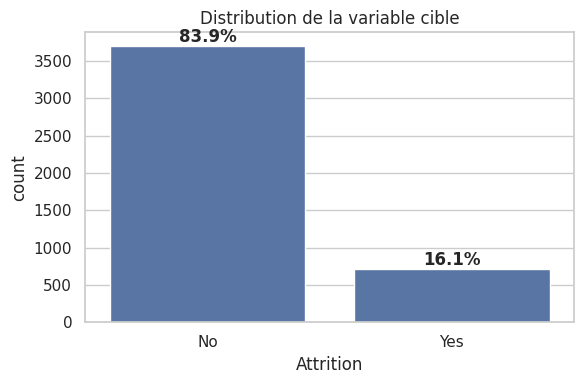

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_merged, x=TARGET, ax=ax)
ax.set_title("Distribution de la variable cible")

# Annoter les barres avec les pourcentages
total = len(df_merged)
for p in ax.patches:
    pct = f"{p.get_height() / total * 100:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 7. Détection d'outliers sur les variables numériques

### Méthode
1. **`describe()`** pour repérer rapidement les min/max suspects
   (ex: un âge de 0 ou un salaire négatif)
2. **Boxplots** pour visualiser la dispersion et les points au-delà
   des moustaches (1.5 x IQR par défaut dans Seaborn)

### Attention
Un outlier n'est pas forcément une erreur. Un salaire très élevé peut être celui
d'un dirigeant. La décision de traiter ou conserver un outlier est **métier**, pas technique.

In [42]:
# Sélection automatique des colonnes numériques (sans l'identifiant)
num_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != KEY]

print(f"{len(num_cols)} colonnes numériques détectées :")
print(num_cols)

20 colonnes numériques détectées :
['Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


In [43]:
# Statistiques descriptives — cherchez les min/max incohérents
df_merged[num_cols].describe().round(2)

,Age,DistanceFromHome,Education,EmployeeCount,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,4410.00,4410.00,4410.00,4410.0,4410.00,4410.00,4391.00,4410.00,4410.0,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00,4385.00,4390.00,4372.00,4410.00,4410.00
mean,36.92,9.19,2.91,1.0,2.06,65029.31,2.69,15.21,8.0,0.79,11.28,2.80,7.01,2.19,4.12,2.72,2.73,2.76,2.73,3.15
std,9.13,8.11,1.02,0.0,1.11,47068.89,2.50,3.66,0.0,0.85,7.78,1.29,6.13,3.22,3.57,1.09,1.10,0.71,0.71,0.36
min,18.00,1.00,1.00,1.0,1.00,10090.00,0.00,11.00,8.0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,3.00
25%,30.00,2.00,2.00,1.0,1.00,29110.00,1.00,12.00,8.0,0.00,6.00,2.00,3.00,0.00,2.00,2.00,2.00,2.00,2.00,3.00
50%,36.00,7.00,3.00,1.0,2.00,49190.00,2.00,14.00,8.0,1.00,10.00,3.00,5.00,1.00,3.00,3.00,3.00,3.00,3.00,3.00
75%,43.00,14.00,4.00,1.0,3.00,83800.00,4.00,18.00,8.0,1.00,15.00,3.00,9.00,3.00,7.00,4.00,4.00,3.00,3.00,3.00
max,60.00,29.00,5.00,1.0,5.00,199990.00,9.00,25.00,8.0,3.00,40.00,6.00,40.00,15.00,17.00,4.00,4.00,4.00,4.00,4.00


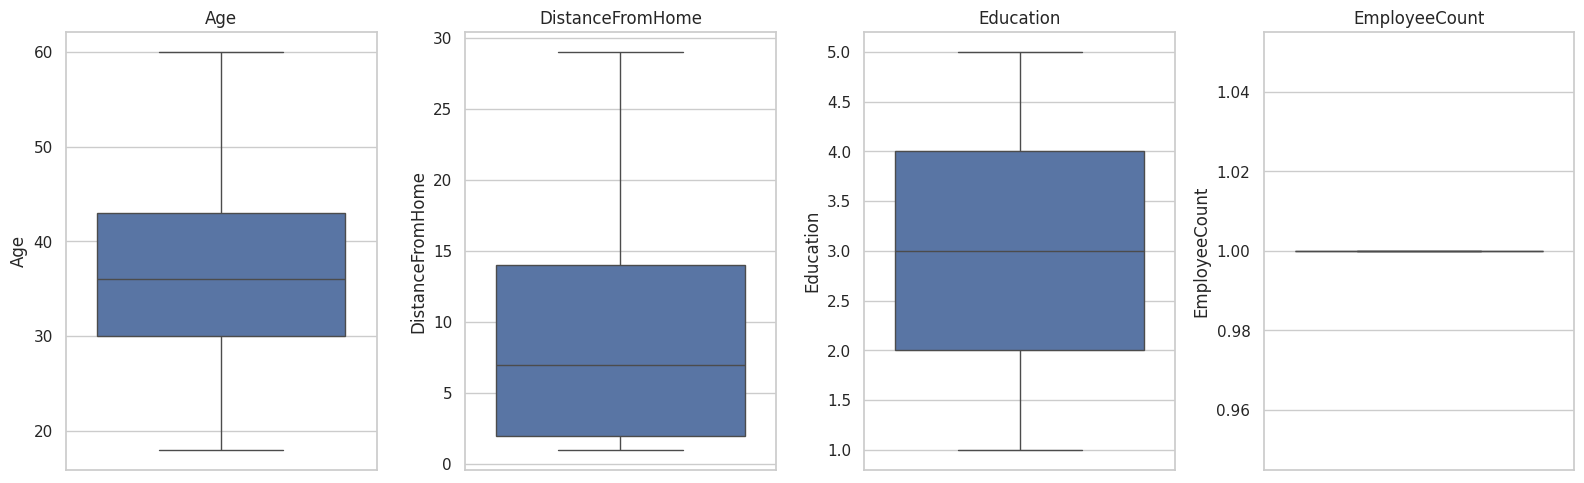

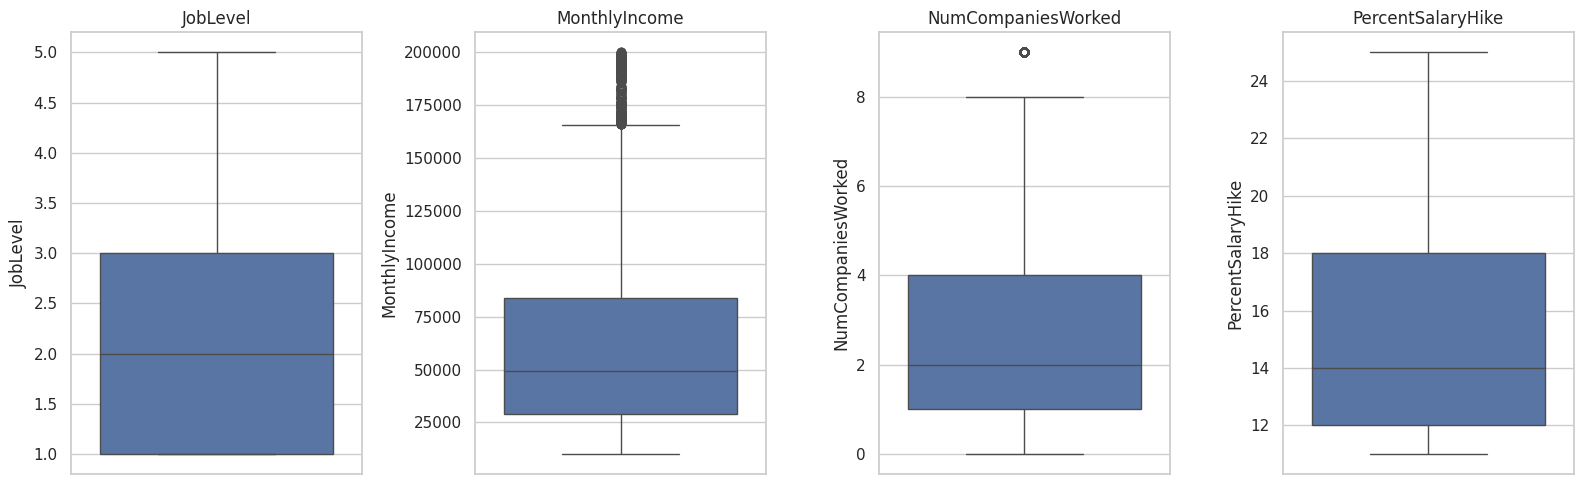

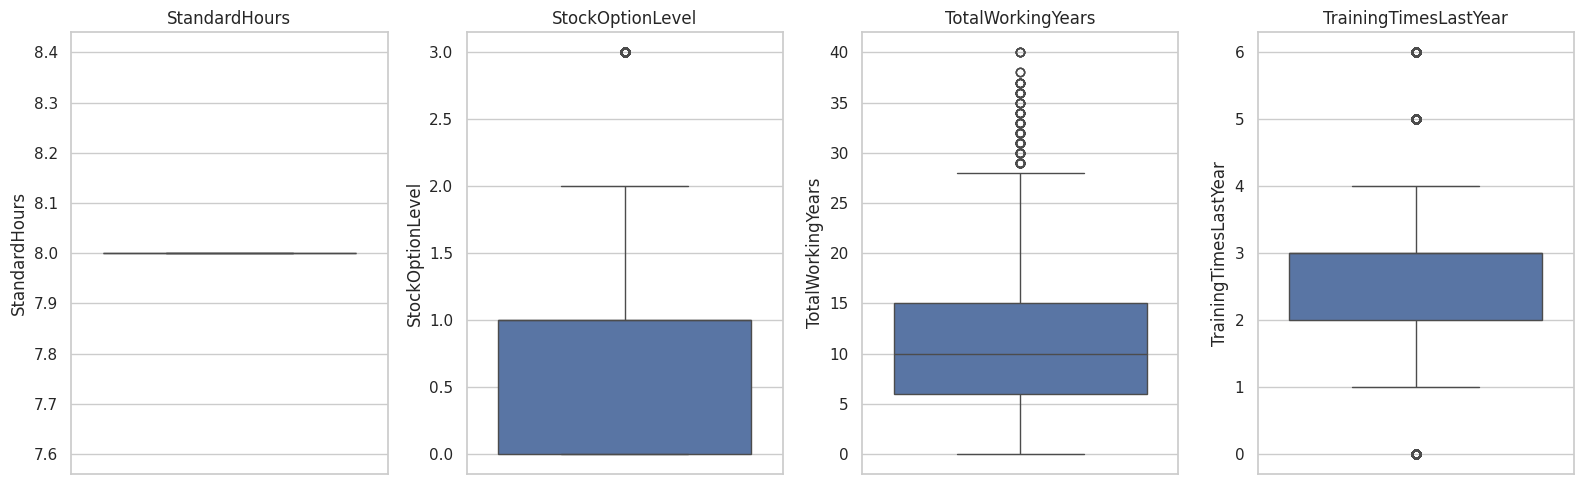

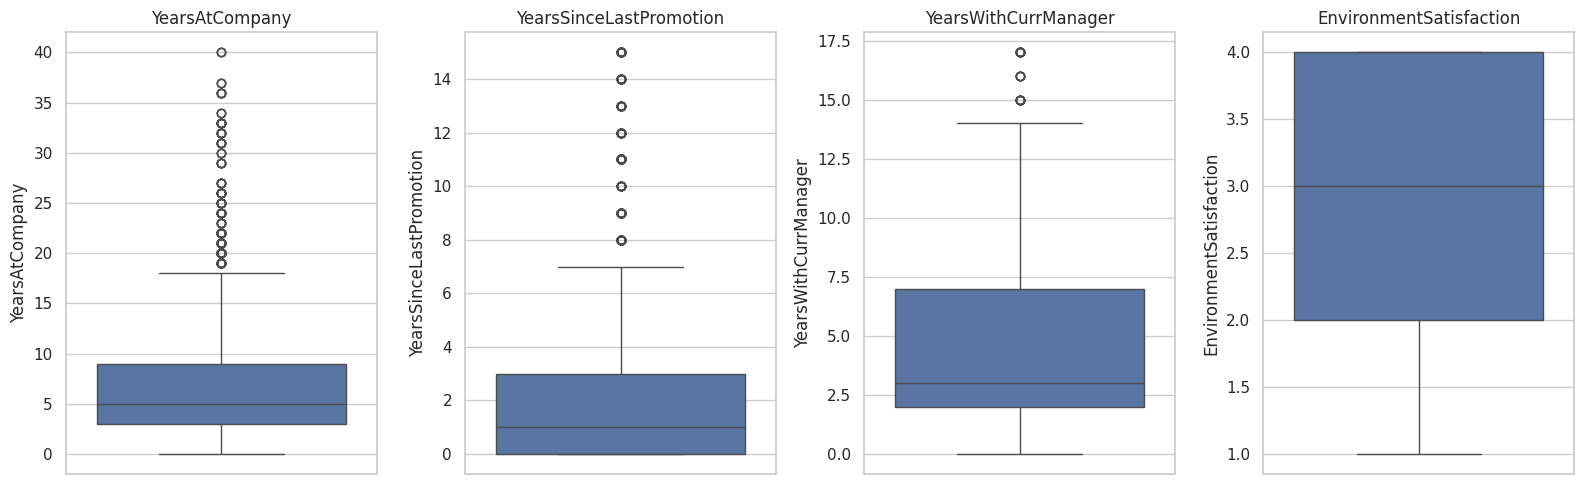

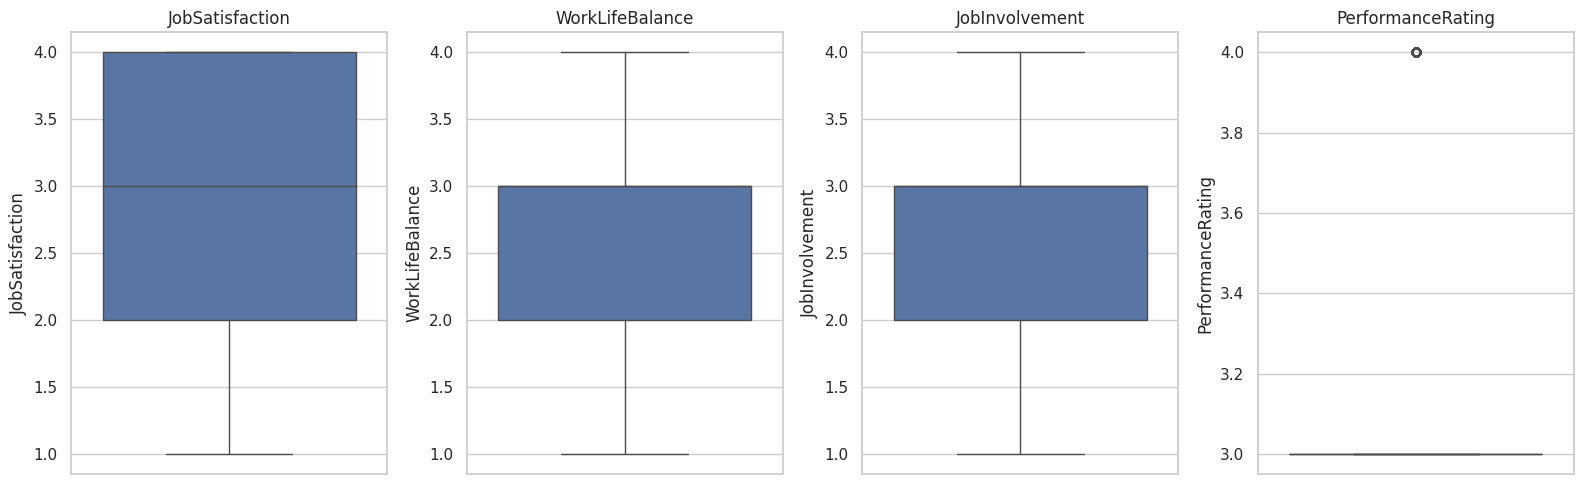

In [44]:
# Boxplots par groupes de colonnes (pour éviter un graphique illisible)
COLS_PER_FIG = 4

for i in range(0, len(num_cols), COLS_PER_FIG):
    subset = num_cols[i : i + COLS_PER_FIG]
    fig, axes = plt.subplots(1, len(subset), figsize=(4 * len(subset), 5))
    if len(subset) == 1:
        axes = [axes]
    for ax, col in zip(axes, subset):
        sns.boxplot(y=df_merged[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

### Observations — Outliers et colonnes suspectes

**Colonnes à variance nulle (std = 0) :**
- `EmployeeCount` : toutes les valeurs = [...] → décision : [garder / supprimer] car [...]
- `StandardHours` : toutes les valeurs = [...] → décision : [garder / supprimer] car [...]
- `Over18` : vérifier avec `df_merged["Over18"].nunique()` → [...]

**Colonnes à très faible variance :**
- `PerformanceRating` : seulement les valeurs [...] et [...] → est-ce un vrai signal ou un biais d'évaluation ? [...]

**Outliers détectés sur les boxplots :**
- `MonthlyIncome` : valeurs extrêmes hautes → erreur ou salaire de dirigeant ? Croisez avec `JobLevel` pour vérifier : [...]
- `YearsAtCompany` / `TotalWorkingYears` : max = 40 → cohérent avec l'âge max de 60 ? [...]
- Autres observations : [...]

**Décisions finales :**
- Colonnes à **supprimer** avant modélisation : [...]
- Outliers à **traiter** : [...]
- Outliers à **conserver** (cas métier légitimes) : [...]

---
## 6. Réflexion Éthique

Nous venons de fusionner des données RH générales (âge, genre, salaire) avec des réponses
issues d'**enquêtes de satisfaction** et d'**évaluations managériales**.

Ces enquêtes ont souvent été remplies par les employés sous une promesse implicite
ou explicite de **confidentialité**.

### Question
Si votre modèle de prédiction d'attrition exploite les scores de satisfaction pour identifier
les employés sur le départ, quel impact cela pourrait-il avoir sur la **confiance des employés**
envers les futures enquêtes internes ?

Quel principe parmi les **7 exigences de l'UE pour une IA de confiance** est directement concerné ?

> *Notez votre réflexion ici avant de poursuivre.*